**Name: Ananta Gurung**

**ID: 2414247**

# Implementation of MCP Neuron for AND and OR Function.

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This function implements basic AND operations with MCP Neuron for two inputs.

    Arguments:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    T (int): Threshold value.

    Returns:
    state_neuron (list): Output of neuron (1 or 0).
    """

    assert len(X1) == len(X2)

    state_neuron = []

    # Element-wise addition and threshold check
    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [ ]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.

    Arguments:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    T (int): Threshold value.

    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        s = X1[i] + X2[i]  # element-wise sum

        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [ ]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


**Question - 1: List out all the limitations of MCP - Neurons**

* Complex connectivity patterns i.e.

* Represents single neuron only

* Processing of continuous values

* A measure of importance

* A learning procedure



**Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.**

MCP neurons cannot directly model XOR, but it can be simulated using if - else logic.

if X1 == X2:

   output = 0

else:

   output = 1

# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI and ML/week 3/mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


**Question - 1: What does the shape of X represent?**

Shape of X represents the number of samples and number of features in data.

**Question - 2: What does the shape of y represent?**

Shape of y represents contains the number of labels (targets) for each data point

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Viewing the Dataset.

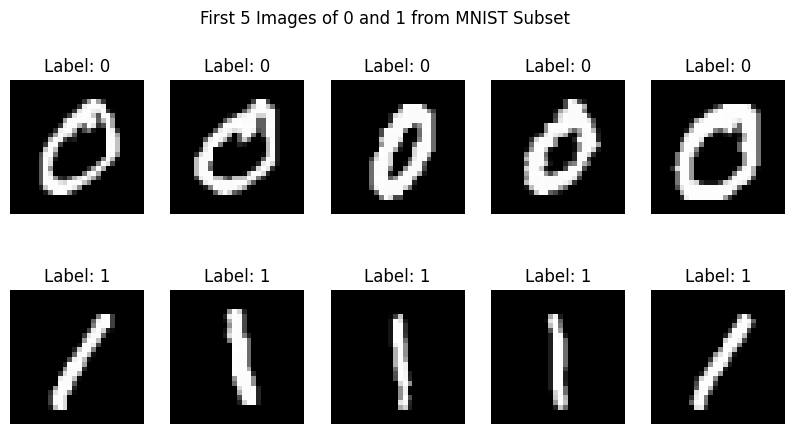

In [ ]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

**Question - 3: What does the weights array represent in this context?**

Weights array contains weights for each feature

**Question - 4: Why are we initializing the weights to zero? What effect could this
have on the training process?**

Its a simple starting point to treat all pixels equally. No feature (pixel) is assumed important at the beginning




## Step - 3 - Make a Decision function:

In [ ]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias

    # Step activation function
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [ ]:
import numpy as np

def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
    """

    for epoch in range(epochs):
        for i in range(len(X)):
            # Step 1: Linear combination
            linear_output = np.dot(X[i], weights) + bias

            # Step 2: Activation function (step function)
            y_pred = 1 if linear_output >= 0 else 0

            # Step 3: Update rule
            weights += learning_rate * (y[i] - y_pred) * X[i]
            bias += learning_rate * (y[i] - y_pred)

    # Step 4: Calculate accuracy
    correct = 0
    for i in range(len(X)):
        y_pred = 1 if (np.dot(X[i], weights) + bias) >= 0 else 0
        if y_pred == y[i]:
            correct += 1

    accuracy = correct / len(X)

    return weights, bias, accuracy

**Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?**

output = np.dot(X[i], weights) + bias line computes the weighted sum of inputs + bias, which is the decision value used to classify the sample.

**Question - 6: What happens when the prediction is wrong? How are the weights and
bias updated?**

When the perceptron makes a wrong prediction, it adjusts its weights and bias to correct that mistake for future inputs. It computes the error as the difference between the true label and the predicted label
(
𝑦
−
𝑦
pred
)
(y−y
pred
	​
), which can be +1 or −1. If the model predicts 0 when it should be 1, the error is +1, so it increases the weights and bias, pushing the decision value higher next time for similar inputs. If it predicts 1 when it should be 0, the error is −1, so it decreases the weights and bias, lowering the decision value. If the prediction is correct, no update is made. In this way, the perceptron gradually shifts its decision boundary so that it better separates the data and reduces future mistakes.


**Question - 7:Why is the final accuracy important, and what do you expect it to be?**

The final accuracy is important because it tells you how well the perceptron has learned to classify the training data after all the updates to weights and bias. It measures the proportion of correctly predicted samples, giving a clear indication of whether the model has successfully found a decision boundary that separates the classes. If the accuracy is high, it means the model has learned the pattern effectively; if it is low, the model has not learned properly or the data may not be suitable for a perceptron.

I would expect the accuracy to be very high (close to 100%) if the data is linearly separable, since a perceptron can perfectly separate such data. However, if the data is not linearly separable (like XOR), the accuracy will not reach 100%, no matter how long you train, because the perceptron cannot represent such complex boundaries.

## Training the Perceptron

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  1.0


## Step 5: Visualize Misclassified Images

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


**Question - 8:What does misclassified idx store, and how is it used in this code?**

misclassified_idx stores the indices of all the data points where the model’s predictions do not match the true labels. It is created using np.where(y_pred != y)[0], which first checks where the predicted values differ from the actual values and then returns the positions of those mismatches. These indices are then used to access the corresponding samples in the dataset. In the code, misclassified_idx is used inside a loop to select up to 10 (incorrectly classified) images, display them using matplotlib, and label each image with its predicted and true values. This helps in visually analyzing the mistakes made by the model and understanding where it is going wrong.


**Question - 9: How do you interpret the result if the output is ”All images were
correctly classified!”?**

If the output says “All images were correctly classified!”, it means the model achieved 100% accuracy on the dataset being evaluated, and there are no misclassified samples

# Implementation for 3 Vs. 5 Classification.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI and ML/week 3/mnist_3_and_5.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (3 or 5)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


### Viewing the Dataset.

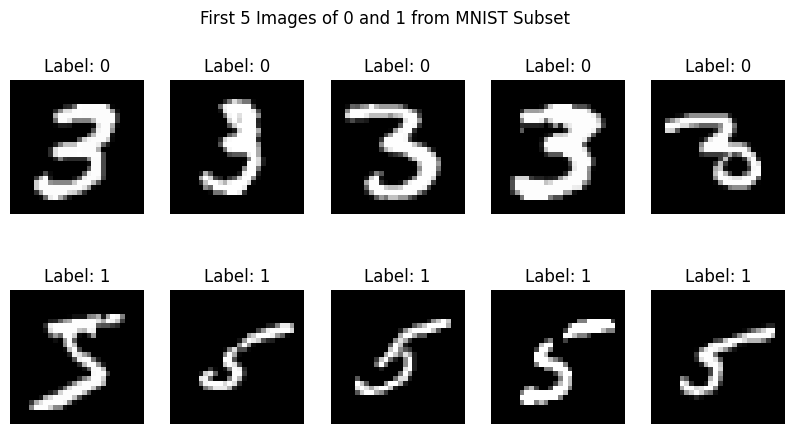

In [ ]:
# Separate images for label 3 and label 5
images_3 = X[y == 3]  # Get all images with label 3
images_5 = X[y == 5]  # Get all images with label 5

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

## Step - 3 - Implement the Perceptron Learning Algorithm

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    # Convert labels: 5 → 1, 3 → 0
    y_binary = np.where(y == 5, 1, 0)

    for epoch in range(epochs):
        for i in range(len(X)):

            linear_output = np.dot(X[i], weights) + bias
            y_pred = 1 if linear_output >= 0 else 0

            # Update
            weights += learning_rate * (y_binary[i] - y_pred) * X[i]
            bias += learning_rate * (y_binary[i] - y_pred)

    # Accuracy
    correct = 0
    for i in range(len(X)):
        y_pred = 1 if (np.dot(X[i], weights) + bias) >= 0 else 0

        if y_pred == y_binary[i]:
            correct += 1

    accuracy = correct / len(X)

    return weights, bias, accuracy

## Training the Perceptron

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  0.986866107260124


## Step 5: Visualize Misclassified Images

Final Accuracy: 0.9869


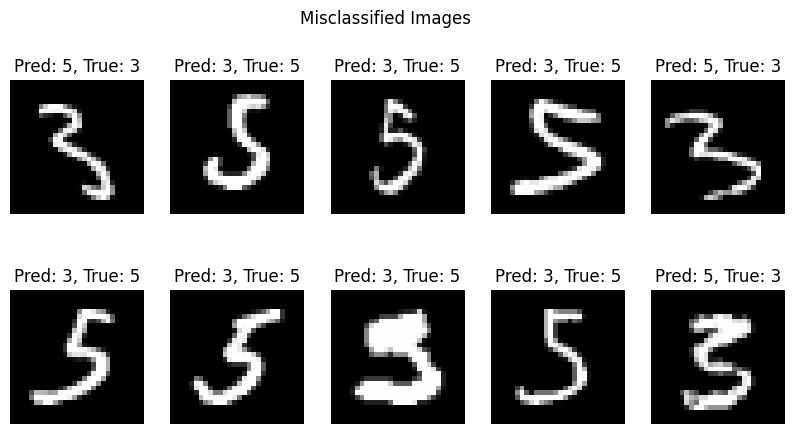

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 5, 3)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")